# Final Exam - DS4DS

## General information

This is the problem description for the final project of the course *"Data Science for Dynamical Systems"* (Winter Term 2025/26)
- February 24th or March 10th

Submission before your presentation (via moodle)
- your slides
- your program code

### Grading
For your assessment, we will grade the following parts of your final project
- quality and clarity of the presentation
- your modeling choices and the reasons for your choices
- your approach to data preparation and analysis
- your technical realization (e.g., choice of algorithms, implementation, ...)
- the results as well as their presentation / visualization
- analysis and interpretation of the reseults
- your replies in the consecutive Q&A session

Each participant will be graded invididually, and we expect everyone to participate in the preparation as well as the presentation.

### Tasks
Below, you will find two tasks. One is concerned with data-driven prediction of a large-scale system, the second one with data-driven control of an ODE.

#### IMPORTANT: out of these, you should only select **one** task as your project!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Prediction of reduced PlanetSWE

##### **Dataset:**
* We reduced the PlanetSWE dataset (see https://polymathic-ai.org/the_well/datasets/planetswe/ for details on the original dataset), in the following way:
    * Downsampling of the $256 \times 512$ data images to $128 \times 256$ via mean-pooling.
    * Removing the "height" data-field, such that only the velocity vector field remains. (meaning each time-slice is of shape $2 \times 128 \times 256$)
    * Retaining only the first $1008$ time steps of the original $3024$.
    * Reducing to only $20$ of the $40$ trajectories.
* We have the time scale $(t_0,t_e)=(0,1008)$, with $dt$ of $1$ hour, thus $24$ timesteps for one day and thus $1008/24 = 42$ days.

**Loading**
* The dataset is split into several .zip files, many `train_[...].zip` and one `test_16_19.zip`, containing .npy files.
* **Each .npy file is one entire trajectory!**
* Loading one trajectory, for example the first `X = np.load({path_to_folder}/planetswe_IC00_s1)`, gives you a numpy array of shape `(1008, 2, 128, 256)`.

*Animation of the velocity-magnitude for $200$ time steps, projected onto a sphere:*

![simulation](planetswe_200.gif)

---

#### **Task:**
* **Train a model using this dataset that predicts the system behavior as accurately as possible.**
* You can choose any model presented in the lecture or exercises.

**Initialization**
* As initial condition take the 24th time-step (beginning of day 2, `X[24, :, :, :]`)
* If you decide to use a model with memory, you may use the entire day 1 for initialization, time steps $0$ to $23$: `X[0:24, :, :, :]`

**Train & Test**
* **Only use the trajectories in the `train_[...].zip` for training.**
* Use `test_16_19.zip` for testing.
* The error should be measured as the MSE between the predicted state and the ground truh (i.e., the given data).

---

**Regarding higher computational requirements**
* If you have a CUDA or ROCm capable GPU locally, consider installing PyTorch with the respective compute platform (https://pytorch.org/get-started/locally/)
* You may also use TUDo's LiDO3 cluster (https://lido.itmc.tu-dortmund.de/)
* Otherwise, consider dimensionality reduction techniques, or further downsampling of the data

In [ ]:
##### EXAMPLE FOR 3D MAPPING #####

velocity = np.load("example_time_step.npy") # equal to X[0] of the trajectory in file planetswe_IC00_s1.npy
# ----------------------------------------------------------------------------------------------------

# Velocity components
v_theta = velocity[0]
v_phi   = velocity[1]

# Define angular grids
n_theta = v_theta.shape[0]
n_phi   = v_theta.shape[1]

theta = np.linspace(np.pi, 0, n_theta)       # polar angle, reverse order!
phi   = np.linspace(0, 2*np.pi, n_phi)       # azimuthal angle

Theta, Phi = np.meshgrid(theta, phi)

# Convert to Cartesian coordinates for plotting the surface
R = np.ones_like(Theta)                      # unit sphere radius
x_coord = R * np.sin(Theta) * np.cos(Phi)
y_coord = R * np.sin(Theta) * np.sin(Phi)
z_coord = R * np.cos(Theta)

# Compute magnitude
speed_mag = np.sqrt(v_theta**2 + v_phi**2).T    # transpose for matching meshgrid orientation

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# Plot the colored surface on the sphere
surf = ax.plot_surface(
    x_coord,
    y_coord,
    z_coord,
    facecolors=plt.cm.coolwarm(speed_mag / speed_mag.max()),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False
)

ax.set_box_aspect([1,1,1])
ax.set_axis_off()
plt.show()

# Task 2: Control of a pendulum on a cart

We want to study the dynamics of a pendulum on a cart, where $x$ is the position of the cart (with mass $M$) and $\theta$ the angle of the pendulum (with mass $m$).

Our goal is to perform a swing-up from the initial condition with $\theta=\pi$ to the desired angle $\theta=0$. As the control input, we can select the force, i.e., $u=F$.

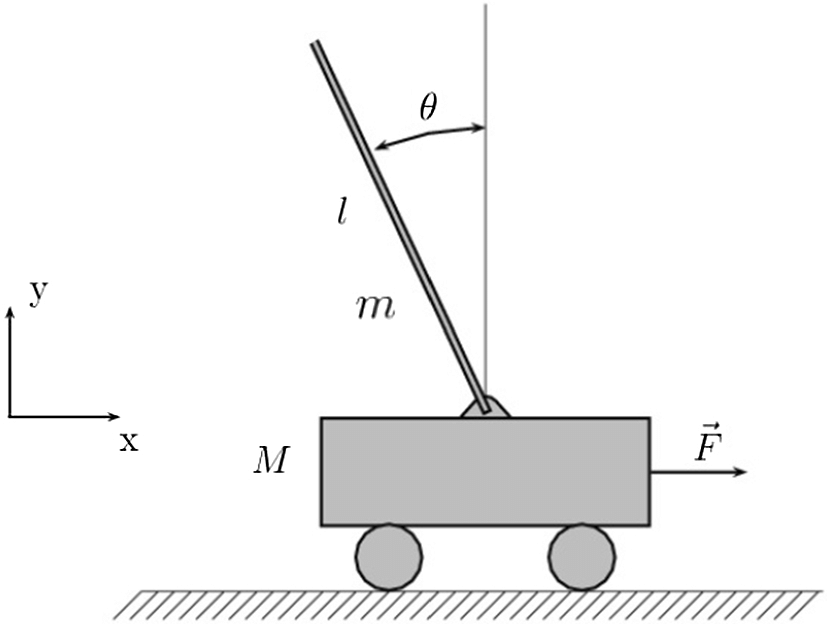

From Newton's law, we obtain the following 2nd order ODEs:
$$
(M+m)\ddot{x} + ml(\ddot{\theta} \cos \theta − (\dot{\theta})^2 \sin \theta)=u,\\ l\ddot{\theta} + g \sin \theta + \ddot{x} \cos \theta = 0.​
$$
By introducing $\dot{x}$ and $\dot{\theta}$ as additional states, one can derive a 1st order ODE in four dimensions for the state $X=[x,\dot{x},\theta,\dot{\theta}]$:
$$
\dot{X}=\begin{bmatrix} \dot{x} \\ \frac{u + ml(\dot{\theta})^2\sin \theta-mg\sin \theta\cos \theta}{M+m(1-\cos^2\theta)} \\ \dot{\theta} \\ \frac{-u\cos\theta - ml(\dot{\theta})^2\sin \theta\cos\theta-(M+m)g\sin\theta}{l(M+m(1-\cos^2\theta))} \end{bmatrix}
$$

### The feedback controller
- we want to find a feedback law $\pi$ such that $ u(t) = \pi(x(t)) $
- the goal is to steer the pendulum towards an upwards position, i.e., $\theta=0$ and $\dot\theta=0$
- for the time horizon, we consider a time of up to $t_e=10$ seconds

### The task
- implement a data-driven feedback controller $\pi$ to achive the swing-up
- a possible performance criterion might be $$\int_{t_0}^{t_e} (\theta(t))^2 + (\dot\theta(t))^2 dt$$ 
- the plant may be used for data collection purposes, but not directly in the control routine
- possible options:
  - model predictive control using a data-driven surrogate model
  - reinforcement learning
  - differentiable predictive control (in that case, you may use the plant in the training routine of the feedback controller)

### The plant
The following code can be used to simulate the plant, and also to create data if you want to train a surrogate model.

In [ ]:
# Physical parameters
M = 1.0   # mass of cart [kg]
m = 0.1   # mass of pendulum [kg]
l = 0.5   # length of pendulum [m]
g = 9.81  # gravity [m/s^2]

def pendulum_dynamics(state, u):
    """
    Continuous-time nonlinear dynamics.
    Returns derivatives: dx/dt = f(state, u)
    """
    x, x_dot, theta, theta_dot = state

    sin_th = np.sin(theta)
    cos_th = np.cos(theta)
    
    denom = M + m * (1 - cos_th**2)

    x_ddot = (u + m*sin_th*(l*theta_dot**2 + g*cos_th)) / denom
    theta_ddot = (-u*cos_th - m*l*theta_dot**2*sin_th*cos_th - (M+m)*g*sin_th) / (l*denom)

    return np.array([x_dot, x_ddot, theta_dot, theta_ddot])


def rk4_step(state, u, dt):
    """One Runge–Kutta-4 integration step."""
    k1 = pendulum_dynamics(state, u)
    k2 = pendulum_dynamics(state + 0.5 * dt * k1, u)
    k3 = pendulum_dynamics(state + 0.5 * dt * k2, u)
    k4 = pendulum_dynamics(state + dt * k3, u)

    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

### Simulation using a sinusoidal control

For your own implementation, replace the line "ui = u[i]" in the for loop by you feedback controller

In [ ]:
# Simulation parameters
dt = 0.01       # time step [s]
T_final = 10.0  # total simulation time [s]
N_steps = int(T_final / dt)

# Initial conditions: pendulum at the bottom
state = np.array([0.0, 0.0, np.pi, 0.0])

# Data storage for plotting later
states_history = np.zeros((N_steps+1, len(state)))
time_history   = np.linspace(0., T_final, N_steps+1)
control_history = np.zeros((N_steps+1, len(state)))
states_history[0] = state

# simple sinusoidal control
u = 0.5 * np.sin(2*(time_history - np.pi/4))

# Step-by-step integration loop (MPC-style interaction possible here!)
for i in range(N_steps):
    
    # Controller computes action based on current state:
    #ui = controller(state)
    ui = u[i]

    # Plant evolves one time step with RK4 integrator:
    next_state = rk4_step(state.copy(), ui, dt)

    # Store and update:
    states_history[i+1] = next_state
    control_history[i] = ui
    state[:] = next_state

In [ ]:
# Plot results:
plt.figure(figsize=(12,5))
plt.subplot(311)
plt.plot(time_history,
         states_history[:, 2]*180/np.pi % 360,
         label="Pendulum angle θ")
plt.ylabel("Angle θ [deg]")
plt.grid(True)

plt.subplot(312)
plt.plot(time_history,
         states_history[:, 0],
         label="Cart position x")
plt.ylabel("Position x [m]")
plt.grid(True)

plt.subplot(313)
plt.plot(time_history[:-1],
         control_history[:-1, 0],
         label="Control u")
plt.ylabel("Control u")
plt.xlabel("Time [s]")
plt.grid(True)

plt.show()

### Your implementation

You can add your code here. It should consist of 
- definition of a feedback control routine
- data collection and training (either of a feedback controller or of a model, which is then used in MPC)

You may be creative in how to approach the architecture, but your decisions should be clearly argued in the final presentation

In [ ]:
def controller(state):
    return 0